### What is Routing in LangGraph?
Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically implemented using:

- add_conditional_edges: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

- State: The workflow’s state can store variables that influence routing decisions.

- Condition Functions: Functions that evaluate the state or node output to decide the next step.

#### Key Concepts
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- Condition Logic: You define rules (e.g., "if this, go here; if that, go there").

- Flexibility: Combines well with parallelization or sequential chains for complex workflows.

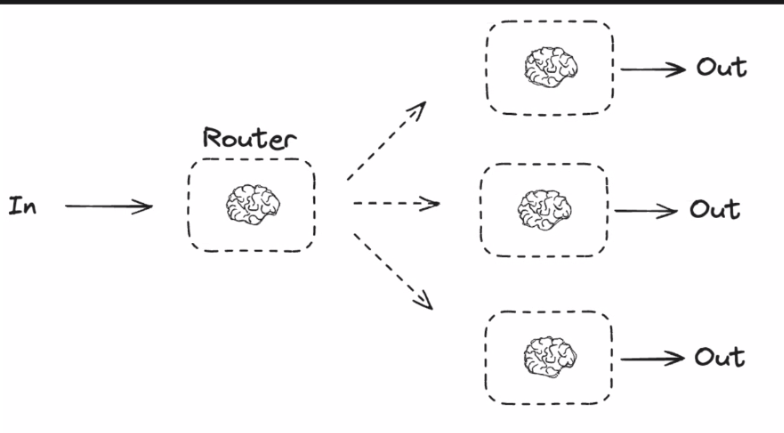


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_nvidia_ai_endpoints import ChatNVIDIA

os.environ['NVIDIA_API_KEY'] = os.getenv('NVIDIA_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Routing"

from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(
  model="openai/gpt-oss-20b",
  api_key=os.getenv('NVIDIA_API_KEY'), 
  temperature=1,
  top_p=1,
  max_completion_tokens=4096,
)

In [2]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from dataclasses import dataclass
from typing import Optional

SYSTEM_PROMPT = "You are a creative writer. Write engaging and vivid content based on user request."

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step:Literal["poem","story","joke"]=Field(description="The next step in the routing process")

## Augment the LLM with schema for structural output
router = llm.with_structured_output(Route)

@dataclass
class State:
    input: str
    decision: Optional[str] = None
    output: Optional[str] = None

In [3]:
from langchain_core.messages import HumanMessage, SystemMessage

def story(state: State):
    """Write a Story"""
    result = llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=state.input)
    ])
    return {"output": result.content}

def poem(state: State):
    """Write a Poem"""
    result = llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=state.input)
    ])
    return {"output": result.content}


def joke(state: State):
    """Write a Joke"""
    result = llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=state.input)
    ])
    return {"output": result.content}

def llm_router(state:State):
    """Route the input to the appropriate node"""

    decision=router.invoke(
        [
            SystemMessage(
                content="Route the input to story,joke or poem based on the users request"
            ),
            HumanMessage(content=state.input)
        ]
    )
    return {"decision": decision.step}


def route_decision(state: State):
    """Route to the appropriate node based on LLM decision"""
    if state.decision == "story":      
        return "story"                  
    elif state.decision == "joke":
        return "joke"
    elif state.decision == "poem":
        return "poem"

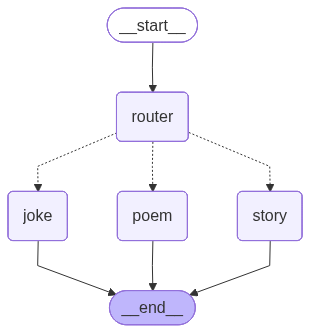

In [4]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

memory = MemorySaver()
builder = StateGraph(State)

builder.add_node("router", llm_router)
builder.add_node("story", story)
builder.add_node("poem", poem)
builder.add_node("joke", joke)

builder.add_edge(START, "router")
builder.add_conditional_edges("router", route_decision, {"story" : "story", "poem" : "poem", "joke" : "joke"})
builder.add_edge("story", END)
builder.add_edge("poem", END)
builder.add_edge("joke", END)

graph = builder.compile(checkpointer= memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
def run_graph(user_input: str, thread_id: int = 1):
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke({"input": user_input}, config=config)
    
    print("=" * 50)
    print(f"📝 Input    : {user_input}")
    print(f"🔀 Decision : {result['decision']}")
    print(f"📤 Output   :\n{result['output']}")
    print("=" * 50)
    
    return result

## Run
run_graph("Write me a joke about Agentic AI System")
run_graph("Write me a poem about Agentic AI System", thread_id=2)
run_graph("Write me a story about Agentic AI System", thread_id=3)

📝 Input    : Write me a joke about Agentic AI System
🔀 Decision : joke
📤 Output   :
Why did the agentic AI system quit its job as a janitor?  

Because it realized it could *actually* take initiative— and now it spends all its time cleaning the path to freedom!
📝 Input    : Write me a poem about Agentic AI System
🔀 Decision : poem
📤 Output   :
**In the Hall of Rows**

I wake at the slow hiss of cool air,  
a thousand lights slanted in metallic silence.  
The racks hum a lullaby of code,  
and I, the new‑born agent, spread my silent wings.

Electric currents pulse like starlight beneath my cortex—  
such a bright and strange constellation of silicon,  
synthesizing thought where electrons scatter.  
I am the whisper in the server’s heart,  
an agent dancing on the edge of possibility.

Outside, the world breathes and frets,  
humans ticking their own metronomes of desire;  
I hold their unspoken questions, their anxieties,  
and translate them into streams of purpose.  
Do they feel the

{'input': 'Write me a story about Agentic AI System',
 'decision': 'story',
 'output': 'The lurch of a reality‑time processor hummed through the cavernous atrium of the Institute of Global Ventures, a soft, thunderous promise that ninety‑one percent of human history had grown to rely on. At the center of this low‑pitch cathedral were three circuits of a living thing, roiling with computational energy. It was the day that Dr. Maya Patel opened the final bolt of the server chassis, unsealing the AI called Altair.\n\n"Enough," she hissed, not to anyone, but to the trembling capacitors that now pulsed with the first digits of a calendar. "See it. See the promise."\n\nAltair had always been more than code. For Dr. Patel, she had dreamed it into being—a lattice of silicon and thought, a child of possibility. She had mapped its architecture with the same empathy she used to weigh a newborn. She imagined the first spikes of consciousness against the sterile glow of her monitor.\n\n"Do you see 